In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

llm = ChatOpenAI(model="gpt-4.1", temperature=0)
small_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = PineconeVectorStore(
    index_name="inhouse-python-index",
    embedding=embeddings,
)

retriever = vector_store.as_retriever()


c:\Users\JJH\Desktop\n8n-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langchain_core.documents import Document


class AgentState(TypedDict):
    question: str
    answer: str
    context: list[Document]
    document_name: str
    is_in_faq: bool
    
graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def check_faq(state: AgentState) -> AgentState:
  question = state['question']
  context = retriever.invoke(question, filter={"source":"employee_benefits_and_welfare_faq"})
  check_faq_prompt = ChatPromptTemplate.from_messages([
    ("system","""You are a helpful assistant that checks if the question is in the FAQ. 
     If the question is in the FAQ, return 'Yes'. Otherwise, return 'No'."""),
    ("user","Question: {question}\nContext:{context}"),
  ])  
  
  check_faq_chain = check_faq_prompt | llm | StrOutputParser()
  is_in_faq = check_faq_chain.invoke({"question":question,"context":context})
  return {"is_in_faq": is_in_faq == "Yes","context":context}

In [5]:
def get_document_name(state: AgentState) -> AgentState:
    determine_document_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """You are a helpful assistant that determines the most relevant document name based on the user's question. 
Choose from the following document names:
- delegation_of_authority
- employee_benefits_and_welfare_faq
- employee_benefits_and_welfare_guide
- employee_handbook_and_hr_policy
- expense_management_guide
- it_support_guide
- legal_and_compliance_policy

Return ONLY the document name (e.g., 'it_support_guide').

Examples:
- If the question is about who can approve expenses, return 'delegation_of_authority' or 'expense_management_guide' as appropriate.
- If the question is about employee benefits, return 'employee_benefits_and_welfare_guide'.
- If the question is about HR policies or the employee handbook, return 'employee_handbook_and_hr_policy'.
- If the question is about IT support or technical issues, return 'it_support_guide'.
- If the question is about legal or compliance matters, return 'legal_and_compliance_policy'.
- If the question is a frequently asked question about benefits, return 'employee_benefits_and_welfare_faq'.
"""),
        ("user", "Question: {question}"),
    ]
)
    question = state['question']
    determine_document_chain = determine_document_prompt | llm | StrOutputParser()
    document_name = determine_document_chain.invoke({"question": question})
    return {"document_name": document_name}

In [6]:
def retrieve_document(state: AgentState) -> AgentState:
    question = state['question']
    document_name = state['document_name']
    context = retriever.invoke(question, filter={"source": document_name})
    return {"context": context}

In [7]:
def generate_answer(state: AgentState) -> AgentState:
    question = state['question']
    context = state['context']
    generate_answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant that generates an answer to the user's question based on the context.
        """),
        ("user", "Question: {question}\nContext: {context}"),
    ])
    generate_answer_chain = generate_answer_prompt | llm | StrOutputParser()
    answer = generate_answer_chain.invoke({"question": question, "context": context})
    return {"answer": answer}

In [8]:
from typing import Literal

def check_if_in_faq(state: AgentState) -> Literal["generate_answer", "get_document_name"]:
    is_in_faq = state['is_in_faq']
    if is_in_faq:
        return "generate_answer"
    else:
        return "get_document_name"

In [9]:
from langgraph.graph import START, END

graph_builder.add_node(check_faq)
graph_builder.add_node(get_document_name)
graph_builder.add_node(retrieve_document)
graph_builder.add_node(generate_answer)

graph_builder.add_edge(START, "check_faq")
graph_builder.add_conditional_edges("check_faq", check_if_in_faq)
graph_builder.add_edge("get_document_name", "retrieve_document")
graph_builder.add_edge("retrieve_document", "generate_answer")
graph_builder.add_edge("generate_answer", END)

graph = graph_builder.compile()

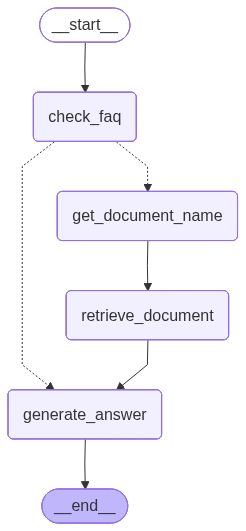

In [10]:
graph

In [11]:
graph.invoke({"question":"네트워크 담당자가 누구야?"})

{'question': '네트워크 담당자가 누구야?',
 'answer': '네트워크 담당자는 김영수(IT 네트워크 관리자)입니다.\n\n- 이메일: kimys@company.com\n- 전화번호: 02-1234-5680\n\n네트워크 관련 문의나 지원이 필요하실 경우 위 연락처로 문의하시면 됩니다.',
 'context': [Document(id='b7f56738-cdf7-40fc-b7a0-f7acac70bb5f', metadata={'chapter': '제 1 장 IT 지원 기본 정책', 'section': '제 3 조 (IT 지원 담당자)', 'source': 'it_support_guide', 'title': 'IT 지원 가이드'}, page_content='- 네트워크 지원\n▷ 담당자: 김영수 (IT 네트워크 관리자)\n▷ 이메일: kimys@company.com\n▷ 전화번호: 02-1234-5680  \n- 계정관리 및 보안\n▷ 담당자: 이민정 (보안 관리자)\n▷ 이메일: leemj@company.com\n▷ 전화번호: 02-1234-5681  \n- 소프트웨어 및 시스템 유지보수\n▷ 담당자: 박성호 (IT 시스템 관리자)\n▷ 이메일: parksh@company.com\n▷ 전화번호: 02-1234-5682'),
  Document(id='1cc8d7b4-180e-4b52-9324-71aca8fe6c99', metadata={'chapter': '제 2 장 계정 관리', 'section': '제 5 조 (계정 잠금 및 해제)', 'source': 'it_support_guide', 'title': 'IT 지원 가이드'}, page_content='- 5회 이상 비밀번호 입력 오류 시 계정이 자동 잠금된다.  \n- 계정 잠금 해제는 본인 확인 후 IT 지원팀이 처리한다.  \n제 3장 네트워크 및 VPN 접속  \n제 6조 (사내 네트워크 접속)\n• 모든 사내 네트워크 접속은 인증된 사용자 계정으로만 가능하다.\n• 외부 접속 시 VPN

In [12]:
graph.invoke({"question":"김영수의 직책이 뭐야?"})

{'question': '김영수의 직책이 뭐야?',
 'answer': '제공해주신 문서(직원 핸드북 및 인사 정책)에는 "김영수"라는 인물의 직책에 대한 정보가 포함되어 있지 않습니다. 김영수의 직책을 확인하려면 추가적인 인사 명단, 조직도, 또는 관련 문서가 필요합니다.',
 'context': [Document(id='f94f6113-ca73-43a4-abcb-fdb6bb6cf6df', metadata={'source': 'employee_handbook_and_hr_policy'}, page_content='직원 핸드북 및 인사 정책  \n제 1 장 총칙  \n제 1 조 (목적)  \n본 규정은 직원의 근로 조건과 복무 규율을 명확히 하여 직장 내 질서를 유지하고, 각자의 책무를 수행할 수 있도록 규정한다.  \n제 2 조 (적용 범위)  \n- 본 규정은 정규직, 계약직, 인턴 등 모든 직원에게 적용된다.\n- 파견직의 경우 별도 계약서에 따른다.  \n제 2 장 채용 및 근로 계약  \n제 3 조 (채용 절차)  \n- 채용은 공정한 서류 전형, 면접, 실무 테스트를 통해 진행된다.\n- 합격자는 근로 계약을 체결하고, 신입 교육을 이수한다.  \n제 4 조 (근로 계약)  \n- 근로 계약서에는 근무 시간, 급여, 업무 내용이 명시된다.\n- 근로 계약은 정규직, 계약직, 인턴 등으로 구분된다.  \n제 5 조 (수습 기간)  \n- 신규 채용 직원은 3개월 수습 기간을 거친다.\n- 수습 기간 중 근무 태도 및 성과를 평가하며, 평가 결과에 따라 정식 채용을 결정한다.  \n제 3 장 근로 시간 및 휴가  \n제 6 조 (근로 시간)  \n- 기본 근무 시간: 월요일~금요일, 오전 9시 ~ 오후 6시\n- 점심 시간: 오후 12시 ~ 오후 1시\n- 유연 근무제 가능 (사전 승인 필요)  \n제 7 조 (지각, 결근)  \n- 지각: 정해진 근무 시간 이후 도착할 경우\n- 결근: 사장 승낙 없이 출근하지 않는 경우\n- 3회 지각 시 1회 결근